In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [40]:
#a mano settali uguali a come runnato in cluster 
#set parameter
test_name = "test_" #inutile
n_runs = 50
n_elems = 60 
n_body_function = 40000 #costo singola iterazione
n_threads = 4
size_queue = 64
n_blocchi = [1,2,4,6,10,12,15,30,60]
sbilanciamento = 10

In [41]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_n_blocchi(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for[0])
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(n_blocchi[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'n_blocchi',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for_sure_n')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.48, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nsetup: range_for({n_elems}), unitary_operation_in_body_function({n_body_function*4})/{n_body_function*4*sbilanciamento}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [42]:
# run test
dati_for = np.genfromtxt("test_for_sbilanciati.txt",delimiter=',',dtype=int)[:-1]
dati_parallel_for_sure_n = []
for i,nb in enumerate(n_blocchi):
    dati_parallel_for_sure_n.append(np.genfromtxt("test_parallel_for_sure_n_sbilanciati"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

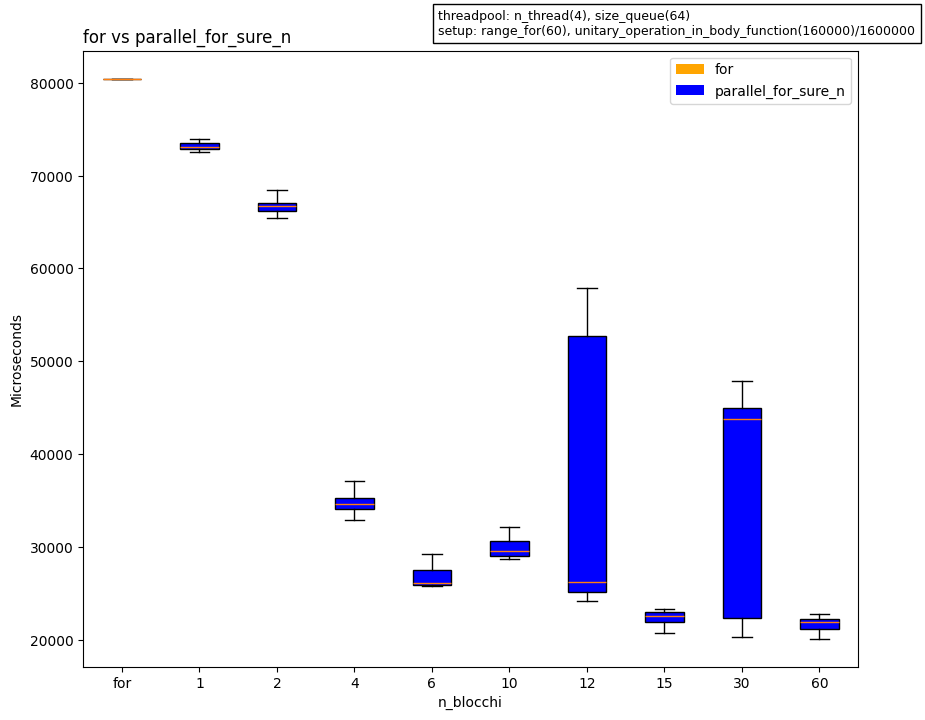

In [43]:
plot_n_blocchi(dati_for, dati_parallel_for_sure_n,"for vs parallel_for_sure_n")


In [44]:
def plot_speedup(data_list,title,n_blocchi,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(n_blocchi))


    for i in range(len(n_blocchi)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    ax.plot(n_blocchi,speedup,'o--')

    y = lambda x: np.minimum(x,n_threads)
    xx = np.array(n_blocchi)
    ax.plot(xx,y(xx),'o--')
    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(n_blocchi)

    ax.set(xlabel = 'n_blocks',ylabel = 'speedup')
    plt.figtext(0.6, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nsetup: range_for({n_elems}), unitary_operation_in_body_function({n_body_function*4})/{n_body_function*4*sbilanciamento}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

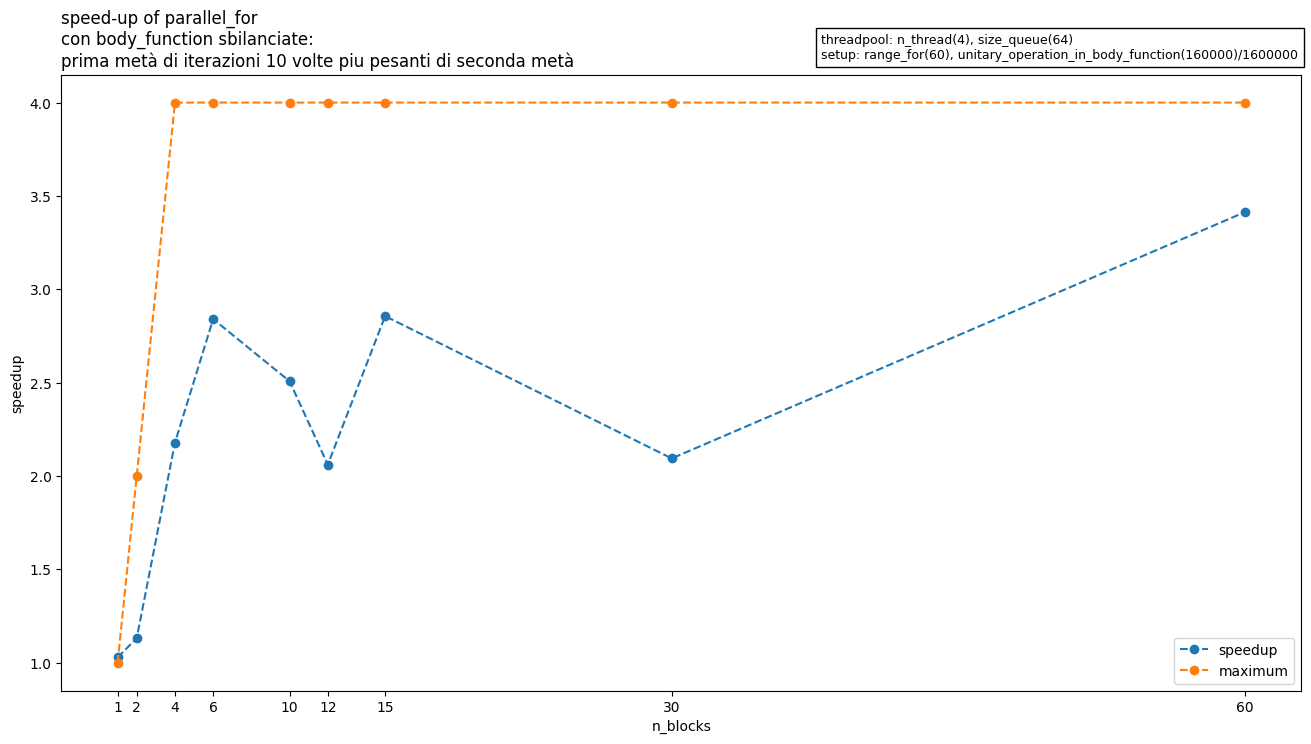

In [45]:
data_list = []
data_list.append(dati_for)
for i in range(len(n_blocchi)):
    dati_parallel_for_sure_n[i] = dati_parallel_for_sure_n[i][dati_parallel_for_sure_n[i]>0]
    data_list.append(dati_parallel_for_sure_n[i])
plot_speedup(data_list,f"speed-up of parallel_for\ncon body_function sbilanciate: \nprima metà di iterazioni {sbilanciamento} volte piu pesanti di seconda metà",n_blocchi,n_threads)